In [1]:
# CamScanner
# Image transformation - Translate, Rotate, Resize
# Perspective

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("doc.webp")

In [4]:
img.shape

(700, 700, 3)

In [5]:
rows, cols = img.shape[:2]

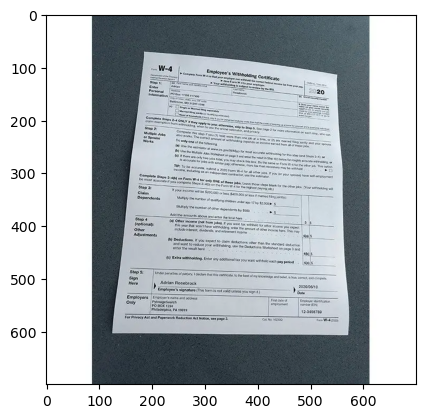

In [7]:
plt.imshow(img)
plt.show()

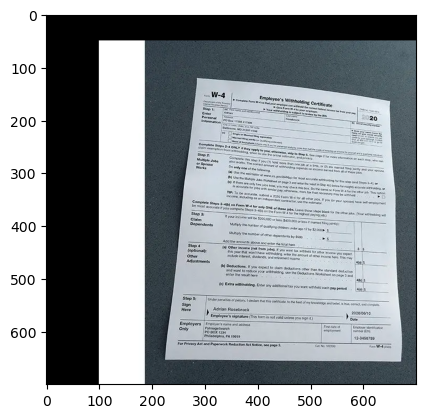

In [9]:
# Create translation matrix
# Format: [[1,0,tx], [0,1,ty]]
# tx - shift along X-axis (right)
# ty - shift along Y-axis (down)

matrix = np.float32([[1,0,100], [0,1,50]])

# Apply translation
translated = cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(translated)
plt.show()

In [10]:
# Rotation
# define center of rotation
center = (cols//2, rows//2)

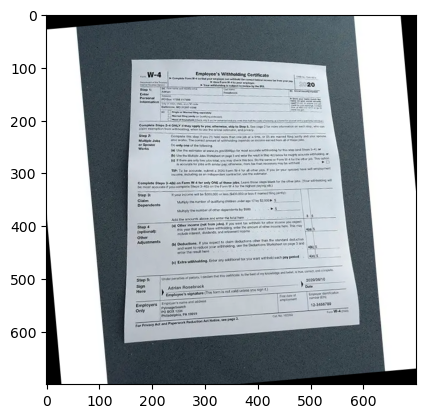

In [15]:
# Parameters: center, angle, scale
# angle - rotation in degrees (positive = counter-clockwise)
# scale - zoom (1 = same size)
matrix = cv2.getRotationMatrix2D(center, 5, 1)

# Apply rotation
rotated = cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(rotated)
plt.show()

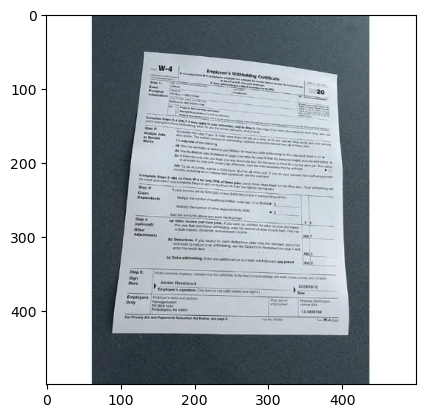

In [16]:
# Resize Image
# Parameters: (image, (width, height))
resized = cv2.resize(img, (500,500))
plt.imshow(resized)
plt.show()

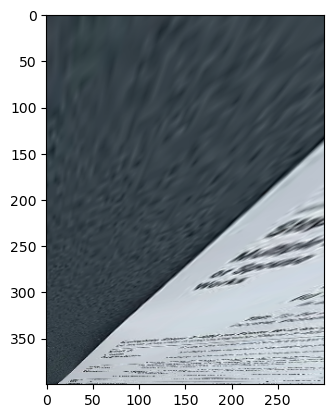

In [27]:
# Perspective Transform
# Concept: tilted document -> top-down flat view
# format - define 4 source points (4 corners of document inoriginal image)
# [top-left, top-right, bottom-right, bottom-left]
points1 = np.float32([[100,150], [150,170], [550,550], [100,550]])

# define destination points
# create a prefect rectangle (flat view)
points2 = np.float32([[0,0], [300,0], [300,400], [0,400]])
matrix = cv2.getPerspectiveTransform(points1, points2)
# Apply perspective
warped = cv2.warpPerspective(img, matrix, (300,400))
plt.imshow(warped)
plt.show()